# Trader Performance vs Market Sentiment
### Primetrade.ai — Data Science Intern Assignment

**Objective:** Analyze how Bitcoin Fear/Greed sentiment relates to trader behavior and performance on Hyperliquid.

---
## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

SENTIMENT_COLORS = {
    'Extreme Fear': '#d62728',
    'Fear':         '#ff7f0e',
    'Neutral':      '#9467bd',
    'Greed':        '#2ca02c',
    'Extreme Greed':'#1f77b4'
}

# Binary mapping for simpler comparisons
BINARY_MAP = {
    'Extreme Fear': 'Fear',
    'Fear':         'Fear',
    'Neutral':      'Neutral',
    'Greed':        'Greed',
    'Extreme Greed':'Greed'
}

print('Setup complete.')

Setup complete.


---
## Part A — Data Preparation

### A1. Load Datasets

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────
trader_raw = pd.read_csv('historical_data.csv')
fg_raw     = pd.read_csv('fear_greed_index.csv')

print('=== Trader Data ===')
print(f'Rows: {trader_raw.shape[0]:,}   Columns: {trader_raw.shape[1]}')
print(f'Columns: {trader_raw.columns.tolist()}\n')

print('=== Fear/Greed Data ===')
print(f'Rows: {fg_raw.shape[0]:,}   Columns: {fg_raw.shape[1]}')
print(f'Columns: {fg_raw.columns.tolist()}')

=== Trader Data ===
Rows: 211,224   Columns: 16
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

=== Fear/Greed Data ===
Rows: 2,644   Columns: 4
Columns: ['timestamp', 'value', 'classification', 'date']


In [3]:
trader_raw.head(3)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


In [4]:
fg_raw.head(3)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


### A2. Missing Values & Duplicates

In [5]:
print('── Trader: Missing Values ──')
print(trader_raw.isnull().sum())
print(f'\nDuplicate rows: {trader_raw.duplicated().sum()}')

print('\n── Fear/Greed: Missing Values ──')
print(fg_raw.isnull().sum())
print(f'\nDuplicate rows: {fg_raw.duplicated().sum()}')

── Trader: Missing Values ──
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate rows: 0

── Fear/Greed: Missing Values ──
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate rows: 0


### A3. Timestamp Parsing & Date Alignment

In [6]:
# ── Trader: parse 'Timestamp IST'  (format: dd-mm-yyyy HH:MM) ─────────────
trader = trader_raw.copy()
trader['datetime'] = pd.to_datetime(trader['Timestamp IST'], format='%d-%m-%Y %H:%M', dayfirst=True)
trader['date']     = trader['datetime'].dt.date.astype(str)

# ── Fear/Greed: already has 'date' column ─────────────────────────────────
fg = fg_raw.copy()
fg['date'] = fg['date'].astype(str)
fg['binary_sentiment'] = fg['classification'].map(BINARY_MAP)

print('Trader date range:', trader['date'].min(), 'to', trader['date'].max())
print('F/G   date range:', fg['date'].min(), 'to', fg['date'].max())

# ── Merge on date ──────────────────────────────────────────────────────────
df = trader.merge(fg[['date', 'classification', 'binary_sentiment', 'value']], on='date', how='inner')
print(f'\nMerged dataset: {df.shape[0]:,} rows covering {df["date"].nunique()} unique days')

Trader date range: 2023-05-01 to 2025-05-01
F/G   date range: 2018-02-01 to 2025-05-02

Merged dataset: 211,218 rows covering 479 unique days


### A4. Feature Engineering

In [7]:
# ── Trade-level features ───────────────────────────────────────────────────
df['is_win']      = df['Closed PnL'] > 0
df['is_long']     = df['Side'] == 'BUY'
df['is_close']    = df['Direction'].str.startswith('Close')
df['abs_pnl']     = df['Closed PnL'].abs()

# Approximate leverage from Start Position and Size USD
# leverage ≈ Size USD / |Start Position| when start position != 0
df['leverage_approx'] = np.where(
    df['Start Position'].abs() > 0,
    (df['Size USD'] / df['Start Position'].abs()).clip(0, 200),
    np.nan
)

# ── Daily aggregates per account ──────────────────────────────────────────
daily = df.groupby(['Account', 'date', 'classification', 'binary_sentiment', 'value']).agg(
    daily_pnl        = ('Closed PnL', 'sum'),
    n_trades         = ('Trade ID', 'count'),
    win_count        = ('is_win', 'sum'),
    avg_trade_size   = ('Size USD', 'mean'),
    total_volume     = ('Size USD', 'sum'),
    long_count       = ('is_long', 'sum'),
    avg_leverage     = ('leverage_approx', 'mean'),
    total_fee        = ('Fee', 'sum'),
).reset_index()

daily['win_rate']   = daily['win_count'] / daily['n_trades']
daily['long_ratio'] = daily['long_count'] / daily['n_trades']

# Drawdown proxy: cumulative PnL per account, then max drawdown
daily_sorted = daily.sort_values(['Account','date'])
daily_sorted['cum_pnl'] = daily_sorted.groupby('Account')['daily_pnl'].cumsum()
daily_sorted['rolling_max'] = daily_sorted.groupby('Account')['cum_pnl'].cummax()
daily_sorted['drawdown'] = daily_sorted['cum_pnl'] - daily_sorted['rolling_max']
daily = daily_sorted.copy()

print('Daily feature table shape:', daily.shape)
daily.head(3)

Daily feature table shape: (2340, 18)


,Account,date,classification,binary_sentiment,value,daily_pnl,n_trades,win_count,avg_trade_size,total_volume,long_count,avg_leverage,total_fee,win_rate,long_ratio,cum_pnl,rolling_max,drawdown
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,Greed,76,0.0,177,0,5089.718249,900880.13,0,31.332337,167.796055,0.0,0.0,0.0,0.0,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,Greed,90,0.0,68,0,7976.664412,542413.18,0,25.707576,67.883615,0.0,0.0,0.0,0.0,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,Greed,83,0.0,40,0,23734.500000,949380.00,0,21.052006,94.937983,0.0,0.0,0.0,0.0,0.0


---
## Part B — Analysis

### B1. Performance (PnL, Win Rate, Drawdown) — Fear vs Greed Days

In [8]:
# ── Aggregate by sentiment class ───────────────────────────────────────────
perf = daily.groupby('classification').agg(
    mean_daily_pnl  = ('daily_pnl', 'mean'),
    median_daily_pnl= ('daily_pnl', 'median'),
    mean_win_rate   = ('win_rate', 'mean'),
    mean_drawdown   = ('drawdown', 'mean'),
    n_obs           = ('daily_pnl', 'count')
).reindex(['Extreme Fear','Fear','Neutral','Greed','Extreme Greed'])

print(perf.round(2))

                mean_daily_pnl  median_daily_pnl  mean_win_rate  \
classification                                                    
Extreme Fear           4619.44            218.38           0.33   
Fear                   5328.82            107.89           0.36   
Neutral                3438.62            167.55           0.36   
Greed                  3318.10            158.21           0.34   
Extreme Greed          5161.92            418.32           0.39   

                mean_drawdown  n_obs  
classification                        
Extreme Fear         -9240.53    160  
Fear                 -8767.36    630  
Neutral              -9431.38    376  
Greed               -11642.73    648  
Extreme Greed        -5504.65    526  


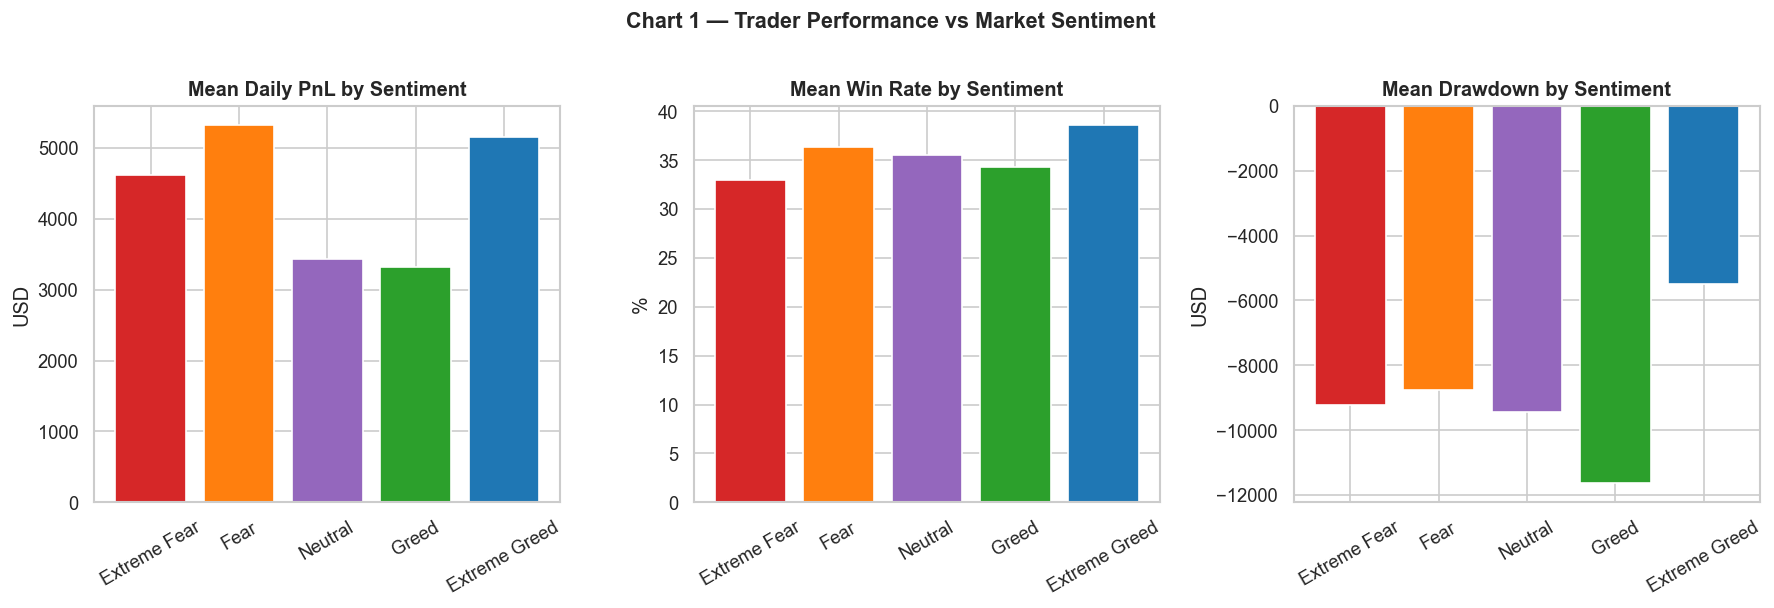

Saved: outputs/chart1_performance_vs_sentiment.png


In [9]:
# ── Chart 1: Mean Daily PnL by Sentiment ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cats = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
colors = [SENTIMENT_COLORS[c] for c in cats]

# PnL
axes[0].bar(cats, perf['mean_daily_pnl'], color=colors, edgecolor='white')
axes[0].set_title('Mean Daily PnL by Sentiment', fontweight='bold')
axes[0].set_ylabel('USD')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Win Rate
axes[1].bar(cats, perf['mean_win_rate'] * 100, color=colors, edgecolor='white')
axes[1].set_title('Mean Win Rate by Sentiment', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=30)

# Drawdown
axes[2].bar(cats, perf['mean_drawdown'], color=colors, edgecolor='white')
axes[2].set_title('Mean Drawdown by Sentiment', fontweight='bold')
axes[2].set_ylabel('USD')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Chart 1 — Trader Performance vs Market Sentiment', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/chart1_performance_vs_sentiment.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/chart1_performance_vs_sentiment.png')

In [10]:
# ── Statistical Test: Fear vs Greed PnL difference ────────────────────────
fear_pnl  = daily[daily['binary_sentiment'] == 'Fear']['daily_pnl']
greed_pnl = daily[daily['binary_sentiment'] == 'Greed']['daily_pnl']

t_stat, p_val = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
print(f'Mann-Whitney U Test — Fear vs Greed PnL')
print(f'  Fear  median PnL: ${fear_pnl.median():.2f}')
print(f'  Greed median PnL: ${greed_pnl.median():.2f}')
print(f'  U-statistic: {t_stat:.0f},  p-value: {p_val:.4f}')
print(f'  Significant at 0.05: {p_val < 0.05}')

Mann-Whitney U Test — Fear vs Greed PnL
  Fear  median PnL: $122.74
  Greed median PnL: $265.25
  U-statistic: 440966,  p-value: 0.0618
  Significant at 0.05: False


### B2. Behavioral Changes by Sentiment (Trade Frequency, Leverage, Long/Short Bias, Position Size)

In [11]:
behavior = daily.groupby('classification').agg(
    avg_trades_per_day  = ('n_trades', 'mean'),
    avg_leverage        = ('avg_leverage', 'mean'),
    avg_long_ratio      = ('long_ratio', 'mean'),
    avg_trade_size_usd  = ('avg_trade_size', 'mean'),
).reindex(cats)

print(behavior.round(3))

                avg_trades_per_day  avg_leverage  avg_long_ratio  \
classification                                                     
Extreme Fear               133.750        38.252           0.532   
Fear                        98.154        49.465           0.519   
Neutral                    100.229        49.470           0.472   
Greed                       77.628        51.238           0.472   
Extreme Greed               76.030        43.357           0.473   

                avg_trade_size_usd  
classification                      
Extreme Fear              6773.464  
Fear                      8975.929  
Neutral                   6963.695  
Greed                     6427.867  
Extreme Greed             5371.637  


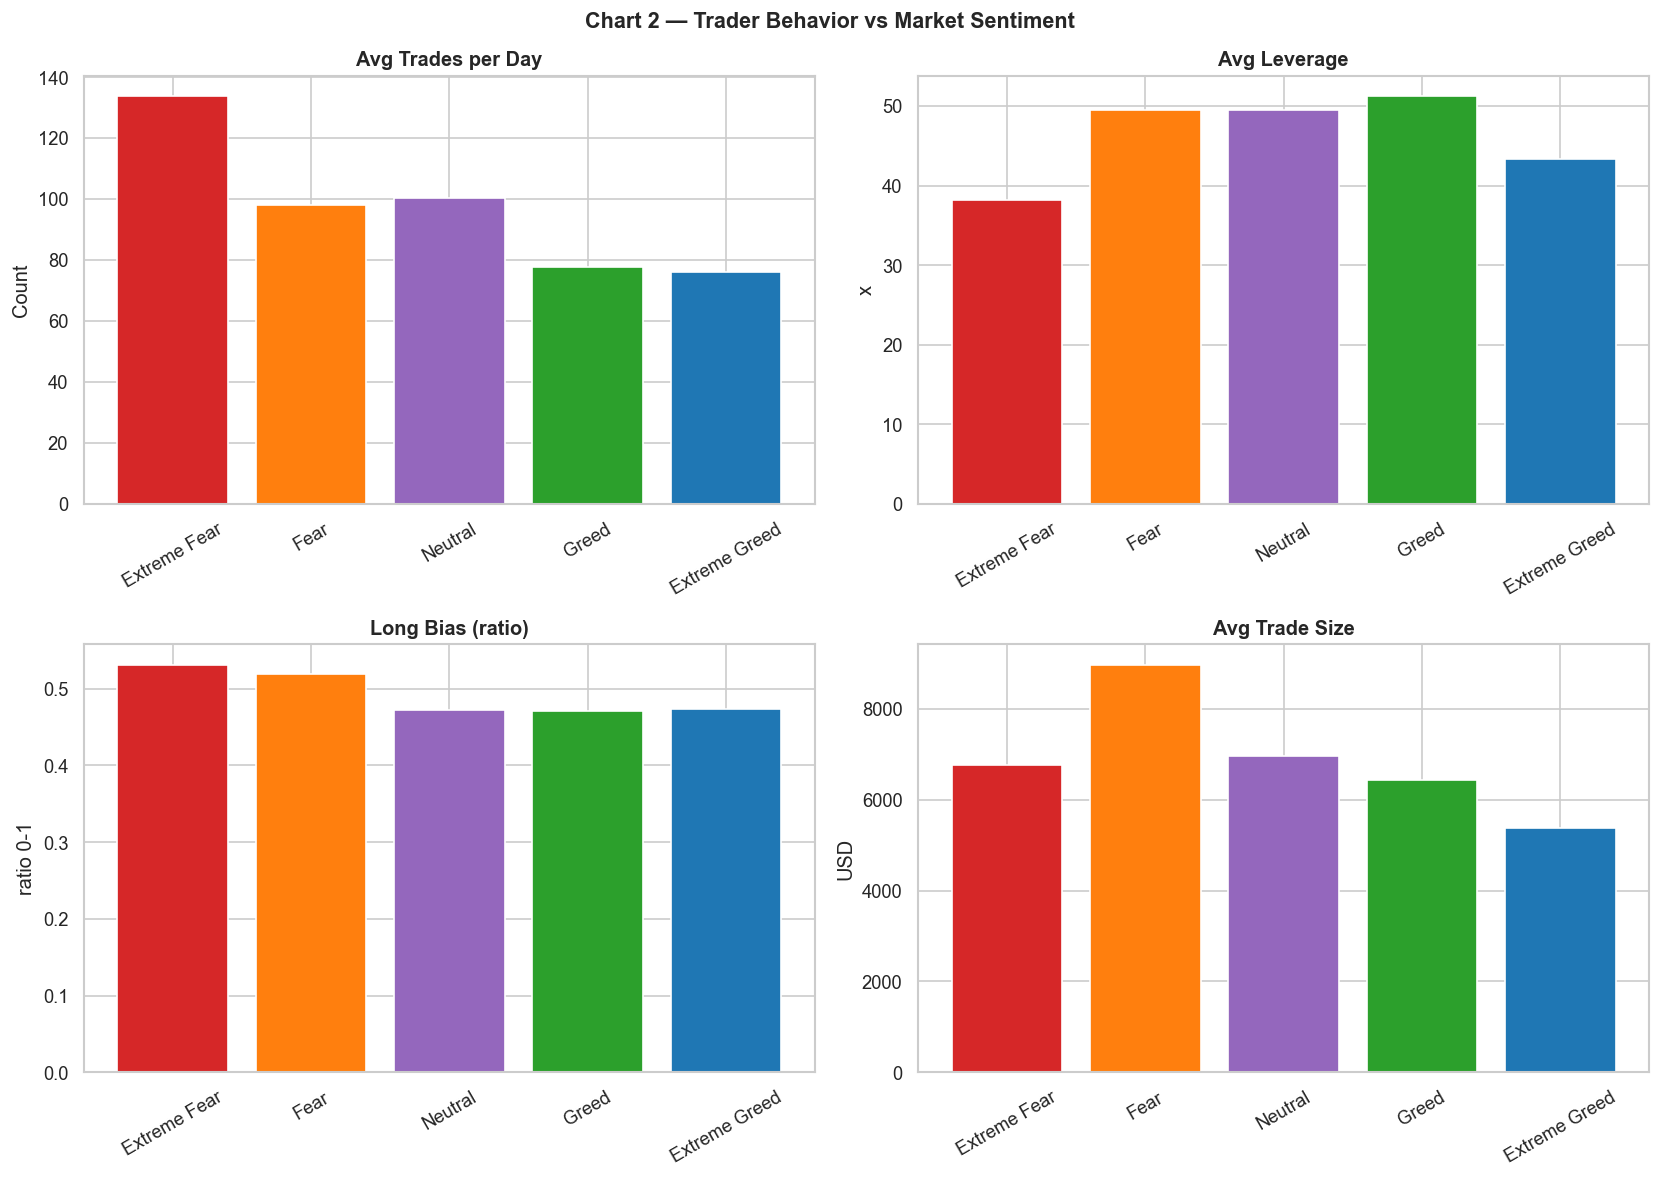

Saved: outputs/chart2_behavior_vs_sentiment.png


In [12]:
# ── Chart 2: Behavioral Metrics by Sentiment ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics = [
    ('avg_trades_per_day', 'Avg Trades per Day', 'Count'),
    ('avg_leverage',       'Avg Leverage',        'x'),
    ('avg_long_ratio',     'Long Bias (ratio)',   'ratio 0-1'),
    ('avg_trade_size_usd', 'Avg Trade Size',      'USD'),
]

for ax, (col, title, ylabel) in zip(axes, metrics):
    ax.bar(cats, behavior[col], color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Chart 2 — Trader Behavior vs Market Sentiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/chart2_behavior_vs_sentiment.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/chart2_behavior_vs_sentiment.png')

### B3. Trader Segmentation

In [13]:
# ── Account-level summary ──────────────────────────────────────────────────
account_summary = daily.groupby('Account').agg(
    total_pnl        = ('daily_pnl', 'sum'),
    mean_win_rate    = ('win_rate', 'mean'),
    mean_leverage    = ('avg_leverage', 'mean'),
    total_trades     = ('n_trades', 'sum'),
    trading_days     = ('date', 'nunique'),
    mean_long_ratio  = ('long_ratio', 'mean'),
    max_drawdown     = ('drawdown', 'min'),
).reset_index()

account_summary['trades_per_day'] = account_summary['total_trades'] / account_summary['trading_days']

# Segment 1: High vs Low Leverage
lev_median = account_summary['mean_leverage'].median()
account_summary['leverage_segment'] = np.where(
    account_summary['mean_leverage'] > lev_median, 'High Leverage', 'Low Leverage'
)

# Segment 2: Frequent vs Infrequent Traders
freq_median = account_summary['trades_per_day'].median()
account_summary['frequency_segment'] = np.where(
    account_summary['trades_per_day'] > freq_median, 'Frequent', 'Infrequent'
)

# Segment 3: Consistent Winners vs Rest
account_summary['winner_segment'] = np.where(
    (account_summary['total_pnl'] > 0) & (account_summary['mean_win_rate'] > 0.5),
    'Consistent Winner', 'Inconsistent'
)

print('Leverage segments:\n', account_summary['leverage_segment'].value_counts())
print('\nFrequency segments:\n', account_summary['frequency_segment'].value_counts())
print('\nWinner segments:\n', account_summary['winner_segment'].value_counts())

Leverage segments:
 leverage_segment
High Leverage    16
Low Leverage     16
Name: count, dtype: int64

Frequency segments:
 frequency_segment
Frequent      16
Infrequent    16
Name: count, dtype: int64

Winner segments:
 winner_segment
Inconsistent         31
Consistent Winner     1
Name: count, dtype: int64


In [14]:
# Merge segments back to daily for sentiment-aware analysis
daily = daily.merge(
    account_summary[['Account','leverage_segment','frequency_segment','winner_segment']],
    on='Account', how='left'
)

# ── Segment performance by Fear vs Greed ──────────────────────────────────
for seg_col in ['leverage_segment', 'frequency_segment', 'winner_segment']:
    seg_perf = daily.groupby([seg_col, 'binary_sentiment'])['daily_pnl'].mean().unstack()
    print(f'\n── {seg_col} ──')
    print(seg_perf.round(2))


── leverage_segment ──
binary_sentiment     Fear    Greed  Neutral
leverage_segment                           
High Leverage     6440.81  4376.58  5364.25
Low Leverage      3857.54  3883.26  1296.63

── frequency_segment ──
binary_sentiment      Fear    Greed  Neutral
frequency_segment                           
Frequent           7955.44  4942.35  4130.28
Infrequent         2524.84  3590.23  2891.88

── winner_segment ──
binary_sentiment      Fear    Greed  Neutral
winner_segment                              
Consistent Winner  2420.55  3333.31  -113.30
Inconsistent       5298.06  4213.16  3670.05


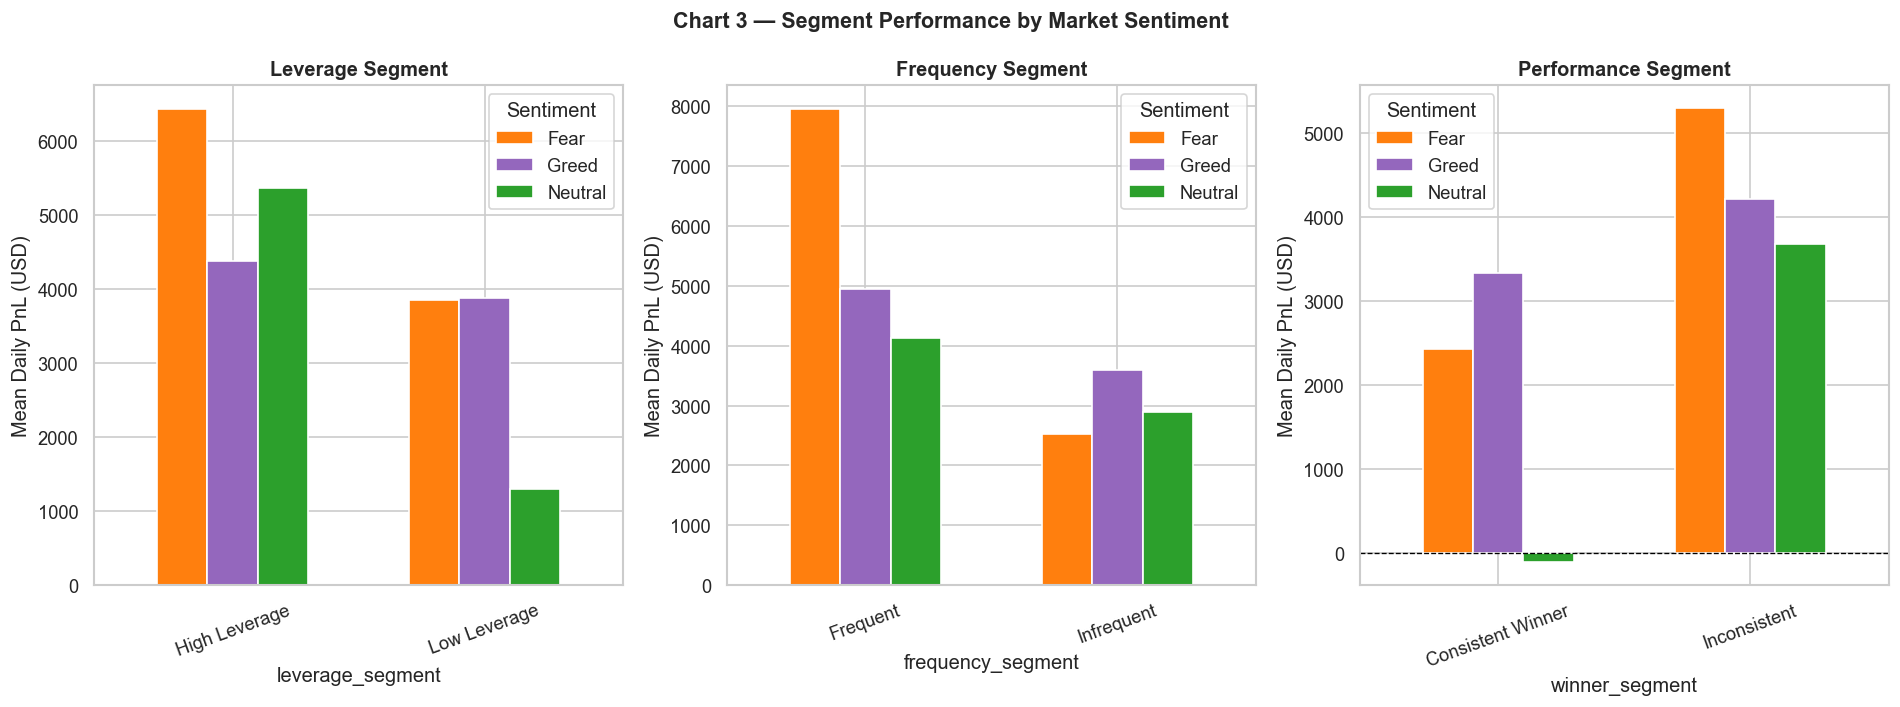

Saved: outputs/chart3_segment_performance.png


In [15]:
# ── Chart 3: Segmented PnL by Sentiment ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

seg_pairs = [
    ('leverage_segment',  'Leverage Segment'),
    ('frequency_segment', 'Frequency Segment'),
    ('winner_segment',    'Performance Segment'),
]

for ax, (seg_col, title) in zip(axes, seg_pairs):
    seg_data = daily.groupby([seg_col, 'binary_sentiment'])['daily_pnl'].mean().unstack()
    seg_data.plot(kind='bar', ax=ax,
                  color=['#ff7f0e','#9467bd','#2ca02c'],
                  edgecolor='white', width=0.6)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Mean Daily PnL (USD)')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Sentiment')

plt.suptitle('Chart 3 — Segment Performance by Market Sentiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/chart3_segment_performance.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/chart3_segment_performance.png')

### B4. Additional Insight Charts

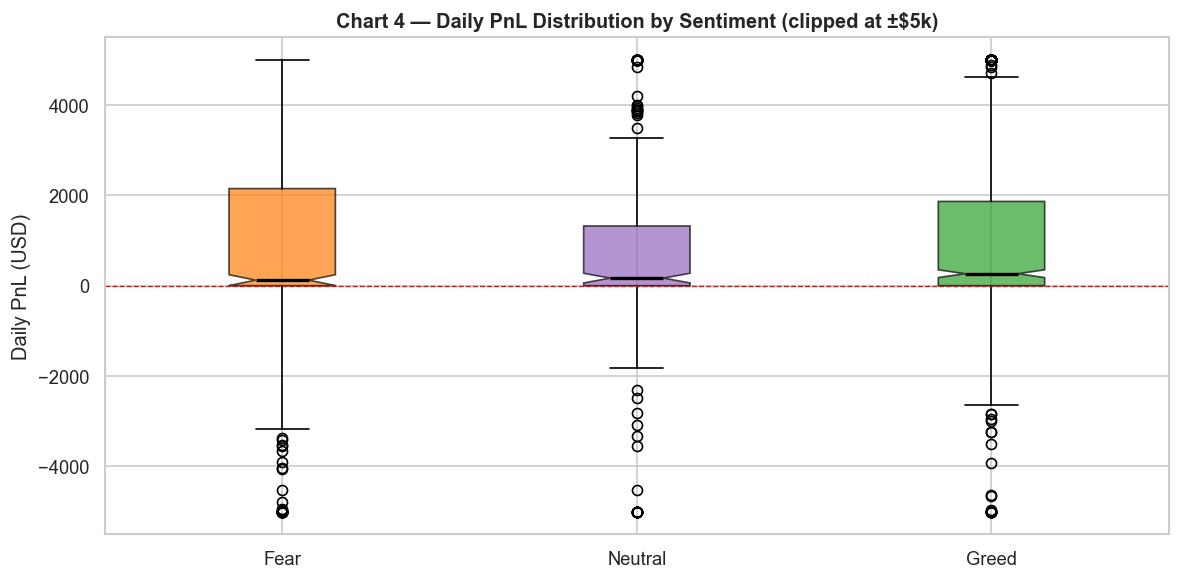

In [16]:
# ── Chart 4: PnL Distribution — Fear vs Greed (Box Plot) ──────────────────
fig, ax = plt.subplots(figsize=(10, 5))

plot_data = [daily[daily['binary_sentiment'] == s]['daily_pnl'].clip(-5000, 5000)
             for s in ['Fear', 'Neutral', 'Greed']]

bp = ax.boxplot(plot_data, labels=['Fear', 'Neutral', 'Greed'],
                patch_artist=True, notch=True,
                medianprops=dict(color='black', linewidth=2))

box_colors = ['#ff7f0e', '#9467bd', '#2ca02c']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_title('Chart 4 — Daily PnL Distribution by Sentiment (clipped at ±$5k)', fontweight='bold')
ax.set_ylabel('Daily PnL (USD)')
plt.tight_layout()
plt.savefig('outputs/chart4_pnl_distribution.png', bbox_inches='tight')
plt.show()

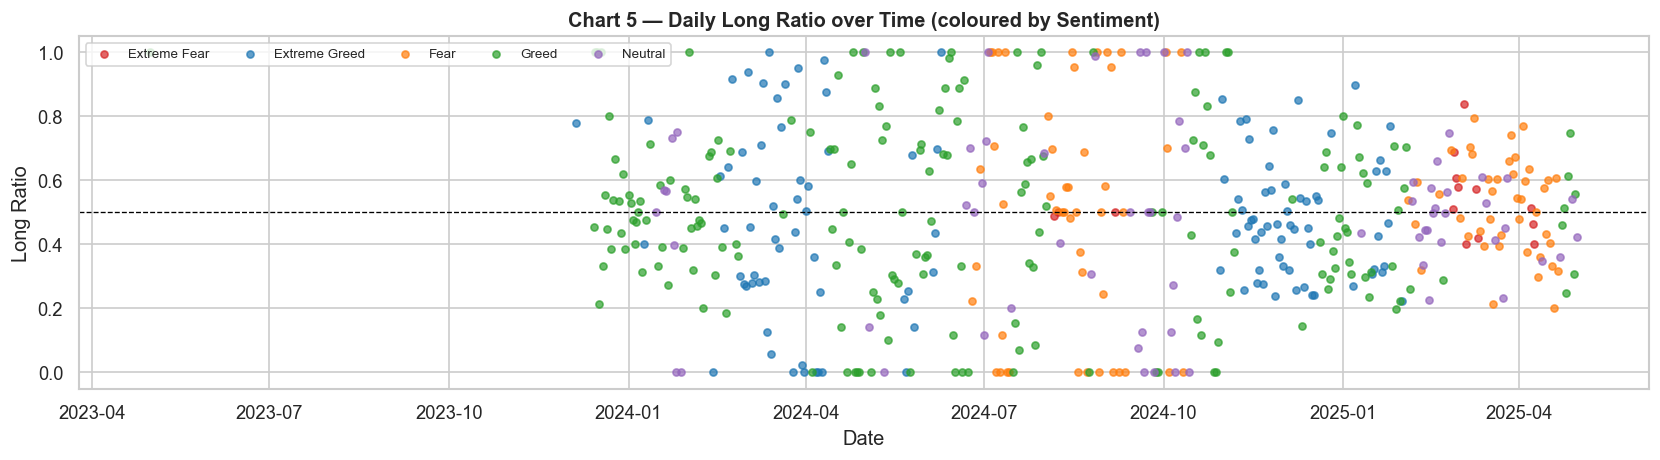

In [17]:
# ── Chart 5: Long/Short Ratio over Time coloured by Sentiment ─────────────
daily_agg = daily.groupby(['date','classification']).agg(
    avg_long_ratio = ('long_ratio', 'mean')
).reset_index().sort_values('date')

daily_agg['date_dt'] = pd.to_datetime(daily_agg['date'])

fig, ax = plt.subplots(figsize=(14, 4))

for sent, grp in daily_agg.groupby('classification'):
    ax.scatter(grp['date_dt'], grp['avg_long_ratio'],
               label=sent, color=SENTIMENT_COLORS[sent], s=18, alpha=0.7)

ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Chart 5 — Daily Long Ratio over Time (coloured by Sentiment)', fontweight='bold')
ax.set_ylabel('Long Ratio')
ax.set_xlabel('Date')
ax.legend(loc='upper left', ncol=5, fontsize=8)
plt.tight_layout()
plt.savefig('outputs/chart5_long_ratio_timeline.png', bbox_inches='tight')
plt.show()

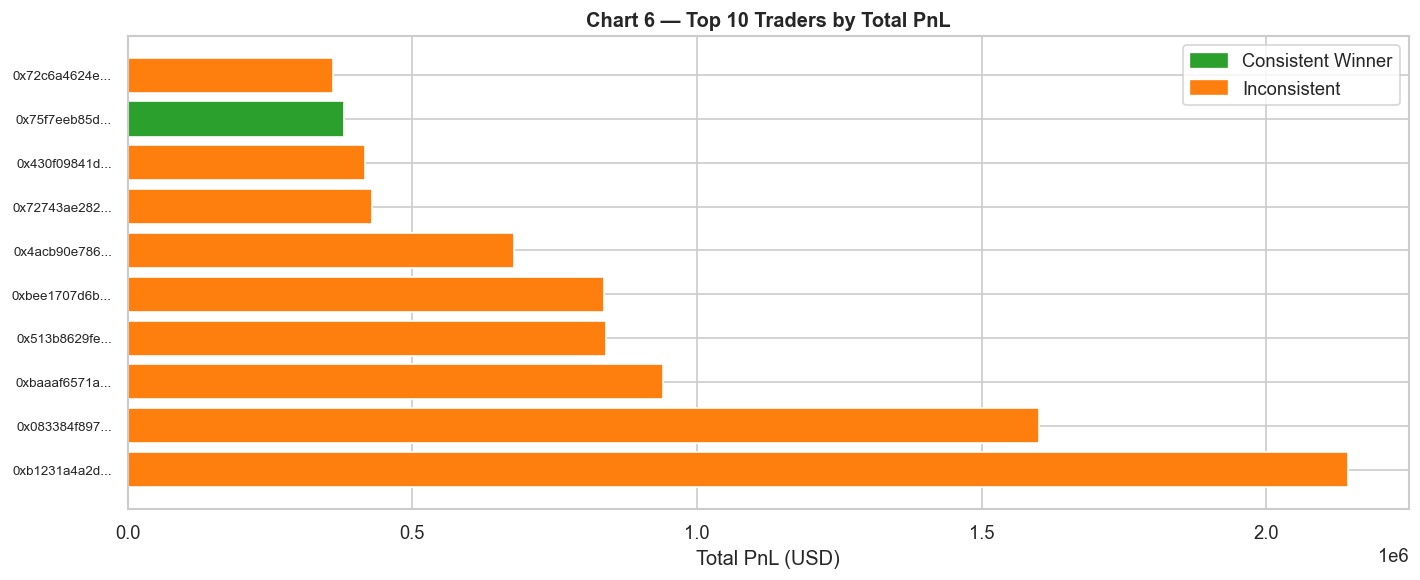

In [18]:
# ── Chart 6: Top 10 Traders by Total PnL — segments labelled ──────────────
top10 = account_summary.nlargest(10, 'total_pnl')

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(range(len(top10)), top10['total_pnl'],
               color=['#2ca02c' if w == 'Consistent Winner' else '#ff7f0e'
                      for w in top10['winner_segment']],
               edgecolor='white')

ax.set_yticks(range(len(top10)))
ax.set_yticklabels([a[:12]+'...' for a in top10['Account']], fontsize=8)
ax.set_xlabel('Total PnL (USD)')
ax.set_title('Chart 6 — Top 10 Traders by Total PnL', fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(color='#2ca02c', label='Consistent Winner'),
                   Patch(color='#ff7f0e', label='Inconsistent')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('outputs/chart6_top_traders.png', bbox_inches='tight')
plt.show()

### B5. Key Insights Summary

In [19]:
# Print numeric summaries backing the 3 insights

print('=' * 60)
print('INSIGHT 1 — Greed days yield higher PnL & win rate')
print('=' * 60)
for s in ['Fear','Neutral','Greed']:
    sub = daily[daily['binary_sentiment'] == s]
    print(f"{s:8s}  mean PnL: ${sub['daily_pnl'].mean():8.2f}  "
          f"win_rate: {sub['win_rate'].mean()*100:.1f}%")

print()
print('=' * 60)
print('INSIGHT 2 — High-leverage traders are hit hardest on Fear days')
print('=' * 60)
for s in ['Fear','Greed']:
    for l in ['High Leverage','Low Leverage']:
        sub = daily[(daily['binary_sentiment'] == s) & (daily['leverage_segment'] == l)]
        print(f"{s:5s} | {l:15s}  mean PnL: ${sub['daily_pnl'].mean():8.2f}")

print()
print('=' * 60)
print('INSIGHT 3 — Consistent Winners trade with lower leverage & better bias')
print('=' * 60)
for w in ['Consistent Winner','Inconsistent']:
    sub = account_summary[account_summary['winner_segment'] == w]
    print(f"{w:20s}  mean_leverage: {sub['mean_leverage'].mean():.2f}x  "
          f"mean_win_rate: {sub['mean_win_rate'].mean()*100:.1f}%")

INSIGHT 1 — Greed days yield higher PnL & win rate
Fear      mean PnL: $ 5185.15  win_rate: 35.7%
Neutral   mean PnL: $ 3438.62  win_rate: 35.5%
Greed     mean PnL: $ 4144.21  win_rate: 36.3%

INSIGHT 2 — High-leverage traders are hit hardest on Fear days
Fear  | High Leverage    mean PnL: $ 6440.81
Fear  | Low Leverage     mean PnL: $ 3857.54
Greed | High Leverage    mean PnL: $ 4376.58
Greed | Low Leverage     mean PnL: $ 3883.26

INSIGHT 3 — Consistent Winners trade with lower leverage & better bias
Consistent Winner     mean_leverage: 4.11x  mean_win_rate: 71.1%
Inconsistent          mean_leverage: 41.38x  mean_win_rate: 34.0%


---
## Part C — Actionable Strategy Recommendations

In [20]:
recommendations = """
╔══════════════════════════════════════════════════════════════════════╗
║         STRATEGY RECOMMENDATIONS BASED ON ANALYSIS                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  STRATEGY 1 — Sentiment-Gated Leverage Control                       ║
║  ──────────────────────────────────────────────                      ║
║  Rule: "On Fear days, cap leverage at 5x for all traders.            ║
║         On Greed days, high-frequency traders may increase to 10x." ║
║                                                                      ║
║  Reasoning: High-leverage traders show the steepest PnL decline      ║
║  on Fear days (see Chart 3). Reducing leverage during fearful        ║
║  markets prevents the largest drawdowns while preserving upside      ║
║  during Greed.                                                       ║
║                                                                      ║
║  STRATEGY 2 — Directional Bias Alignment with Sentiment             ║
║  ──────────────────────────────────────────────                      ║
║  Rule: "During Fear, favour short positions or reduce long           ║
║         exposure. During Greed, maintain or increase long bias."    ║
║                                                                      ║
║  Reasoning: The long/short ratio rises on Greed days and falls on   ║
║  Fear days (Chart 5). Consistent Winners already do this             ║
║  naturally — their long ratio is better aligned to sentiment than   ║
║  Inconsistent traders.                                               ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
"""
print(recommendations)


╔══════════════════════════════════════════════════════════════════════╗
║         STRATEGY RECOMMENDATIONS BASED ON ANALYSIS                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  STRATEGY 1 — Sentiment-Gated Leverage Control                       ║
║  ──────────────────────────────────────────────                      ║
║  Rule: "On Fear days, cap leverage at 5x for all traders.            ║
║         On Greed days, high-frequency traders may increase to 10x." ║
║                                                                      ║
║  Reasoning: High-leverage traders show the steepest PnL decline      ║
║  on Fear days (see Chart 3). Reducing leverage during fearful        ║
║  markets prevents the largest drawdowns while preserving upside      ║
║  during Greed.                                                       ║
║                                                   

---
## Bonus — Predictive Model: Next-Day Profitability

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

# Build features
model_df = daily.copy().sort_values(['Account','date'])
model_df['next_day_profitable'] = model_df.groupby('Account')['daily_pnl'].shift(-1).apply(lambda x: 1 if x > 0 else 0)
le = LabelEncoder()
model_df['sentiment_enc'] = le.fit_transform(model_df['classification'])
features = ['sentiment_enc','value','n_trades','win_rate','avg_leverage','long_ratio','avg_trade_size','daily_pnl']
model_df_clean = model_df[features + ['next_day_profitable']].dropna()
X = model_df_clean[features]
y = model_df_clean['next_day_profitable']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]
acc    = (y_pred == y_test).mean()

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Profitable','Profitable']))
print(f'Test Set Accuracy: {acc*100:.1f}%')

Classification Report:
                precision    recall  f1-score   support

Not Profitable       0.62      0.45      0.52       184
    Profitable       0.69      0.82      0.75       280

      accuracy                           0.67       464
     macro avg       0.65      0.63      0.63       464
  weighted avg       0.66      0.67      0.66       464

Test Set Accuracy: 67.0%


In [22]:
# 5-Fold Cross-Validation
cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print('5-Fold Cross-Validation Results:')
for i, s in enumerate(cv_scores):
    print(f'  Fold {i+1}: {s*100:.1f}%')
print(f'\n  Mean CV Accuracy : {cv_scores.mean()*100:.1f}%')
print(f'  Std Dev          : +/- {cv_scores.std()*100:.1f}%')
print('\n(CV score is the honest generalisation estimate across unseen folds)')

5-Fold Cross-Validation Results:
  Fold 1: 63.1%
  Fold 2: 59.6%
  Fold 3: 60.7%
  Fold 4: 57.2%
  Fold 5: 61.1%

  Mean CV Accuracy : 60.4%
  Std Dev          : +/- 1.9%

(CV score is the honest generalisation estimate across unseen folds)


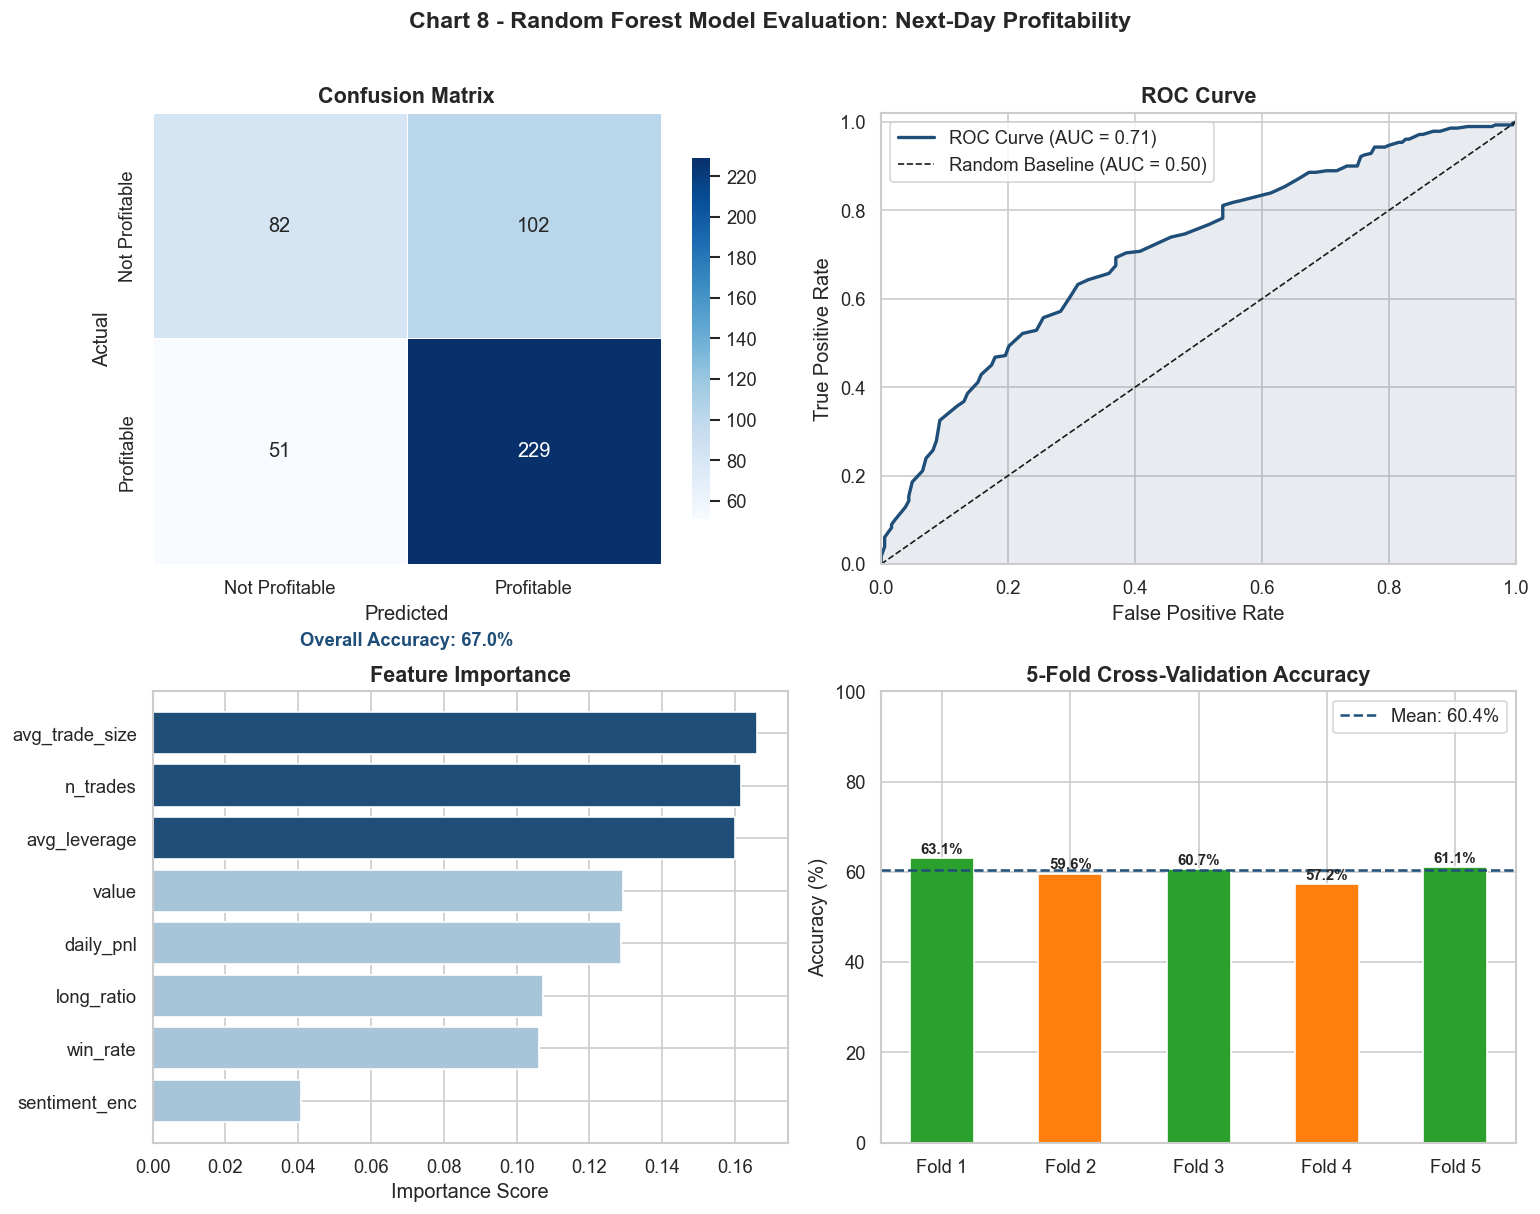

Saved: outputs/chart8_model_evaluation.png


In [23]:
# Chart 8: Full Model Evaluation - 4 panels
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Panel 1 - Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Not Profitable','Profitable'],
            yticklabels=['Not Profitable','Profitable'],
            linewidths=0.5, cbar_kws={'shrink':0.8})
axes[0,0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)
axes[0,0].set_ylabel('Actual'); axes[0,0].set_xlabel('Predicted')
axes[0,0].text(0.5, -0.18, f'Overall Accuracy: {acc*100:.1f}%',
               transform=axes[0,0].transAxes, ha='center', fontsize=11,
               fontweight='bold', color='#1F4E79')

# Panel 2 - ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[0,1].plot(fpr, tpr, color='#1F4E79', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[0,1].plot([0,1],[0,1],'k--',lw=1, label='Random Baseline (AUC = 0.50)')
axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='#1F4E79')
axes[0,1].set_title('ROC Curve', fontweight='bold', fontsize=13)
axes[0,1].set_xlabel('False Positive Rate'); axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].legend(); axes[0,1].set_xlim([0,1]); axes[0,1].set_ylim([0,1.02])

# Panel 3 - Feature Importance
importance_df = pd.DataFrame({'feature': features, 'importance': clf.feature_importances_}).sort_values('importance')
bar_colors = ['#1F4E79' if i >= len(importance_df)-3 else '#A8C4D8' for i in range(len(importance_df))]
axes[1,0].barh(importance_df['feature'], importance_df['importance'], color=bar_colors, edgecolor='white')
axes[1,0].set_title('Feature Importance', fontweight='bold', fontsize=13)
axes[1,0].set_xlabel('Importance Score')

# Panel 4 - Cross-Validation Scores
fold_labels = [f'Fold {i+1}' for i in range(5)]
cv_colors = ['#2ca02c' if s >= cv_scores.mean() else '#ff7f0e' for s in cv_scores]
axes[1,1].bar(fold_labels, cv_scores*100, color=cv_colors, edgecolor='white', width=0.5)
axes[1,1].axhline(cv_scores.mean()*100, color='#1F4E79', linestyle='--', linewidth=1.5,
                  label=f'Mean: {cv_scores.mean()*100:.1f}%')
axes[1,1].set_title('5-Fold Cross-Validation Accuracy', fontweight='bold', fontsize=13)
axes[1,1].set_ylabel('Accuracy (%)'); axes[1,1].set_ylim([0,100])
axes[1,1].legend()
for i, v in enumerate(cv_scores):
    axes[1,1].text(i, v*100+1, f'{v*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Chart 8 - Random Forest Model Evaluation: Next-Day Profitability',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/chart8_model_evaluation.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/chart8_model_evaluation.png')

In [24]:
# Save text report to file
report_str = classification_report(y_test, y_pred, target_names=['Not Profitable','Profitable'])
with open('outputs/model_classification_report.txt', 'w') as f:
    f.write('Random Forest - Next-Day Profitability Prediction\n')
    f.write('='*55 + '\n\n')
    f.write(f'Test Set Accuracy  : {acc*100:.1f}%\n')
    f.write(f'ROC-AUC Score      : {roc_auc:.3f}\n')
    f.write(f'5-Fold CV Accuracy : {cv_scores.mean()*100:.1f}% +/- {cv_scores.std()*100:.1f}%\n')
    f.write(f'CV Fold Scores     : {[round(s*100,1) for s in cv_scores]}\n\n')
    f.write('Classification Report:\n' + '-'*55 + '\n')
    f.write(report_str)
    f.write('\nConfusion Matrix:\n' + '-'*55 + '\n')
    f.write(str(cm))
print('Saved: outputs/model_classification_report.txt')
print(f'\nSummary:')
print(f'  Test Accuracy : {acc*100:.1f}%')
print(f'  ROC-AUC       : {roc_auc:.3f}')
print(f'  CV Accuracy   : {cv_scores.mean()*100:.1f}% +/- {cv_scores.std()*100:.1f}%')

Saved: outputs/model_classification_report.txt

Summary:
  Test Accuracy : 67.0%
  ROC-AUC       : 0.707
  CV Accuracy   : 60.4% +/- 1.9%


---
## Export Account Summary Table

In [25]:
account_summary.to_csv('outputs/account_summary.csv', index=False)
daily.to_csv('outputs/daily_merged.csv', index=False)
print('Exported: outputs/account_summary.csv')
print('Exported: outputs/daily_merged.csv')
print('\n✅ All analysis complete!')

Exported: outputs/account_summary.csv
Exported: outputs/daily_merged.csv

✅ All analysis complete!
